
好的，我们一步步推导在 **3 层神经网络** 中使用 **Batch Normalization（批归一化）** 并且激活函数为 **sigmoid** 时的反向传播过程，给出 $ W, b, \gamma, \beta $ 的梯度公式。  

---

## 1. 网络结构定义

我们考虑一个 **3 层全连接网络**（即 2 个隐藏层 + 1 个输出层），结构如下：

- 输入层：$ x $（向量，mini-batch 数据）
- 第 1 层（隐藏层 1）：
  $$
  z^{(1)} = W^{(1)} x + b^{(1)}
  $$
  然后经过 BatchNorm（BN）：
  $$
  y^{(1)} = \text{BN}_{\gamma^{(1)},\beta^{(1)}}(z^{(1)})
  $$
  再经过激活函数（sigmoid）：
  $$
  a^{(1)} = \sigma(\hat{z}^{(1)})
  $$

- 第 2 层（隐藏层 2）：
  $$
  z^{(2)} = W^{(2)} a^{(1)} + b^{(2)}
  $$
  $$
  y^{(2)} = \text{BN}_{\gamma^{(2)},\beta^{(2)}}(z^{(2)})
  $$
  $$
  a^{(2)} = \sigma(\hat{z}^{(2)})
  $$

- 第 3 层（输出层）：
  $$
  z^{(3)} = W^{(3)} a^{(2)} + b^{(3)}
  $$
  这里输出层我们**不加 BN**（常见做法），直接接损失函数（例如 MSE 或 Cross-Entropy）。

---

## 2. BatchNorm 前向传播公式

对于某一层的 BN（以第 $ l $ 层为例，$ l = 1, 2 $）：

对 mini-batch $ z \in \mathbb{R}^{m \times d} $（$ m $ 是 batch size，$ d $ 是该层神经元数）：

$$
\mu = \frac{1}{m} \sum_{i=1}^m z_i
$$
$$
\sigma^2 = \frac{1}{m} \sum_{i=1}^m (z_i - \mu)^2
$$
$$
\hat{z}_i = \frac{z_i - \mu}{\sqrt{\sigma^2 + \epsilon}}
$$
$$
y_i = \gamma \odot \hat{z}_i + \beta
$$
其中 $ \gamma, \beta $ 是可学习的参数（与 $ z $ 同维度，这里逐元素操作），$ \odot $ 是逐元素乘法。

---

## 3. 反向传播梯度推导（链式法则）

我们使用符号：
- $ L $：损失函数
- $ \delta^{(l)} = \frac{\partial L}{\partial z^{(l)}} $（未 BN 的线性输出）
- $ \hat{\delta}^{(l)} = \frac{\partial L}{\partial y^{(l)}} $（BN 后、激活前的值）

---

### 3.1 输出层（第 3 层）梯度

$$
\frac{\partial L}{\partial W^{(3)}} = \delta^{(3)} \cdot (a^{(2)})^T
$$
$$
\frac{\partial L}{\partial b^{(3)}} = \delta^{(3)}
$$
其中：
$$
\delta^{(3)} = \frac{\partial L}{\partial z^{(3)}}
$$
具体形式取决于损失函数，例如 MSE 输出 $ \hat{y} = z^{(3)} $（线性输出）时：
$$
\delta^{(3)} = \hat{y} - y
$$
（若用 softmax + 交叉熵，则 $ \delta^{(3)} = \hat{y} - y $ 同样成立）

---

### 3.2 第 2 层反向传播

第 2 层 BN 输出 $ \hat{z}^{(2)} $ 经过 sigmoid 得 $ a^{(2)} = \sigma(\hat{z}^{(2)}) $。

已知：
$$
\frac{\partial L}{\partial a^{(2)}} = (W^{(3)})^T \delta^{(3)}
$$
$$
\frac{\partial L}{\partial y^{(2)}} = \frac{\partial L}{\partial a^{(2)}} \odot \sigma'(\hat{z}^{(2)})
$$

sigmoid 导数：$ \sigma'(x) = \sigma(x)(1 - \sigma(x)) $，即：

$$
\hat{\delta}^{(2)} = \frac{\partial L}{\partial y^{(2)}} = \big[(W^{(3)})^T \delta^{(3)}\big] \odot \big( a^{(2)} \odot (1 - a^{(2)}) \big)
$$

---

#### 3.2.1 BN 层反向传播

已知 BN 前向：
$$
y = \gamma \odot \hat{z} + \beta,\quad \hat{z} = \frac{z - \mu}{\sqrt{\sigma^2 + \epsilon}}
$$
反向时（对单个样本，但向量形式）：
$$
\frac{\partial L}{\partial \gamma} = \sum_{i=1}^m \frac{\partial L}{\partial y_i} \odot \hat{z}_i
$$
$$
\frac{\partial L}{\partial \beta} = \sum_{i=1}^m \frac{\partial L}{\partial y_i}
$$


---

#### 3.2.2 BN 输入梯度 $ \frac{\partial L}{\partial z^{(2)}} $

BN 反向传播公式（整个 batch，推导见论文或标准公式）：

$$
\frac{\partial L}{\partial z_i} = \frac{\gamma}{m\sqrt{\sigma^2+\epsilon}} \left[ m \cdot \frac{\partial L}{\partial y_i} - \sum_{j=1}^m \frac{\partial L}{\partial y_j} - \hat{z}_i \sum_{j=1}^m \frac{\partial L}{\partial y_j} \odot \hat{z}_j \right]
$$
更常见写法（令 $ \hat{\delta} = \frac{\partial L}{\partial y} $）：
$$
\frac{\partial L}{\partial z_i} = \frac{\gamma}{\sqrt{\sigma^2+\epsilon}} \left[ \hat{\delta}_i - \frac{1}{m}\sum_{j=1}^m \hat{\delta}_j - \frac{1}{m} \hat{z}_i \sum_{j=1}^m \hat{\delta}_j \hat{z}_j \right]
$$
（这里 $ \hat{z}_j $ 是向量，所以 $ \hat{\delta}_j \hat{z}_j $ 是逐元素乘后求和标量？注意：实际是逐元素相乘，然后对 batch 求和得到向量，所以是每个神经元独立做。）

更准确向量形式（对每个神经元 k 独立）：
$$
\frac{\partial L}{\partial z_{i,k}} = \frac{\gamma_k}{\sqrt{\sigma_k^2+\epsilon}} \left[ \hat{\delta}_{i,k} - \frac{1}{m}\sum_{j=1}^m \hat{\delta}_{j,k} - \frac{1}{m} \hat{z}_{i,k} \sum_{j=1}^m \hat{\delta}_{j,k} \hat{z}_{j,k} \right]
$$
所以：
$$
\delta^{(2)} = \frac{\partial L}{\partial z^{(2)}} = \text{BN\_backward}(\hat{\delta}^{(2)}, \hat{z}^{(2)}, \sigma^2, \gamma^{(2)})
$$
其中 BN_backward 就是上面这个公式向量化实现。

---

#### 3.2.3 $ W^{(2)}, b^{(2)} $ 梯度

$$
\frac{\partial L}{\partial W^{(2)}} = \delta^{(2)} (a^{(1)})^T
$$
$$
\frac{\partial L}{\partial b^{(2)}} = \delta^{(2)}
$$
（注意：BN 原论文在训练时会把 $ b $ 去掉，因为 BN 的 $ \beta $ 已含偏置，但这里我们仍保留 $ b $，实际中可设 $ b=0 $）

---

### 3.3 第 1 层反向传播

类似第 2 层：

$$
\frac{\partial L}{\partial a^{(1)}} = (W^{(2)})^T \delta^{(2)}
$$
$$
\hat{\delta}^{(1)} = \frac{\partial L}{\partial y^{(1)}} = \frac{\partial L}{\partial a^{(1)}} \odot \sigma'(\hat{z}^{(1)})
$$
$$
= \big[(W^{(2)})^T \delta^{(2)}\big] \odot \big( a^{(1)} \odot (1 - a^{(1)}) \big)
$$

---

#### 3.3.1 $ \gamma^{(1)}, \beta^{(1)} $ 梯度

$$
\nabla_{\gamma^{(1)}} L = \sum_{i=1}^m \hat{\delta}^{(1)}_i \odot \hat{z}^{(1)}_i
$$
$$
\nabla_{\beta^{(1)}} L = \sum_{i=1}^m \hat{\delta}^{(1)}_i
$$

---

#### 3.3.2 $ \delta^{(1)} $ 计算

$$
\delta^{(1)} = \frac{\partial L}{\partial z^{(1)}} = \text{BN\_backward}(\hat{\delta}^{(1)}, \hat{z}^{(1)}, \sigma_1^2, \gamma^{(1)})
$$

---

#### 3.3.3 $ W^{(1)}, b^{(1)} $ 梯度

$$
\frac{\partial L}{\partial W^{(1)}} = \delta^{(1)} x^T
$$
$$
\frac{\partial L}{\partial b^{(1)}} = \delta^{(1)}
$$

---

## 4. 总结梯度公式

对第 $ l $ 隐藏层（$ l=1,2 $）：

1. **从上一层反向传播得到**：
   $$
   \frac{\partial L}{\partial a^{(l)}} = (W^{(l+1)})^T \delta^{(l+1)}
   $$

2. **经过激活函数导数**：
   $$
   \hat{\delta}^{(l)} = \frac{\partial L}{\partial a^{(l)}} \odot \big( a^{(l)} \odot (1 - a^{(l)}) \big)
   $$

3. **BN 参数梯度**：
   $$
   \nabla_{\gamma^{(l)}} L = \sum_{i=1}^m \hat{\delta}^{(l)}_i \odot \hat{z}^{(l)}_i
   $$
   $$
   \nabla_{\beta^{(l)}} L = \sum_{i=1}^m \hat{\delta}^{(l)}_i
   $$

4. **BN 输入梯度**：
   $$
   \delta^{(l)} = \frac{\gamma^{(l)}}{\sqrt{(\sigma^{(l)})^2+\epsilon}} \left[ \hat{\delta}^{(l)} - \text{mean}(\hat{\delta}^{(l)}) - \hat{z}^{(l)} \odot \text{mean}( \hat{\delta}^{(l)} \odot \hat{z}^{(l)} ) \right]
   $$
   其中 mean 是对 batch 维度的均值。

5. **权重与偏置梯度**：
   $$
   \nabla_{W^{(l)}} L = \delta^{(l)} (a^{(l-1)})^T
   $$
   $$
   \nabla_{b^{(l)}} L = \delta^{(l)}
   $$
   （$ a^{(0)} = x $）

输出层（无 BN）：
$$
\nabla_{W^{(3)}} L = \delta^{(3)} (a^{(2)})^T
$$
$$
\nabla_{b^{(3)}} L = \delta^{(3)}
$$
$$
\delta^{(3)} = \frac{\partial L}{\partial z^{(3)}}
$$
（具体由损失函数决定）

---



推导 **3.2.2 节中的 BN 输入梯度** $\frac{\partial L}{\partial z_i}$。

---

## 1. BN 前向传播回顾

对于一个 mini-batch $ z = [z_1, z_2, \dots, z_m] $（每个 $ z_i $ 是向量，但 BN 对每个神经元独立进行，所以我们先考虑单个神经元/标量情况，然后向量化）：

**前向过程**（对某个神经元，所有样本的值 $ z_1, \dots, z_m $）：

$$
\mu = \frac{1}{m} \sum_{i=1}^m z_i
$$
$$
\sigma^2 = \frac{1}{m} \sum_{i=1}^m (z_i - \mu)^2
$$
$$
\hat{z}_i = \frac{z_i - \mu}{\sqrt{\sigma^2 + \epsilon}}
$$
$$
y_i = \gamma \hat{z}_i + \beta
$$

---

## 2. 已知的反向传播输入

反向时已知：
$$
\frac{\partial L}{\partial y_i} = \hat{\delta}_i
$$
当i=j,$\hat{\delta}_i=1$;当i!=j,$\hat{\delta}_i=0$

我们需要求：
$$
\frac{\partial L}{\partial z_i} = \sum_{j=1}^m \frac{\partial L}{\partial y_j} \frac{\partial y_j}{\partial z_i} + \sum_{j=1}^m \frac{\partial L}{\partial \mu} \frac{\partial \mu}{\partial z_i} + \sum_{j=1}^m \frac{\partial L}{\partial \sigma^2} \frac{\partial \sigma^2}{\partial z_i}
$$
因为 $ \mu, \sigma^2 $ 是 $ z $ 的函数，计算 $ \frac{\partial y_j}{\partial z_i} $ 时必须考虑它们。

---

## 3. 逐步求导

### 3.1 直接项 $ \frac{\partial y_j}{\partial z_i} $

由 $ y_j = \gamma \hat{z}_j + \beta $，且 $ \hat{z}_j = \frac{z_j - \mu}{\sqrt{\sigma^2 + \epsilon}} $。

当 $ j = i $ 时：
$$
\frac{\partial y_i}{\partial z_i} = \gamma \cdot \frac{\partial \hat{z}_i}{\partial z_i}
$$
当 $ j \neq i $ 时，$ z_j $ 与 $ z_i $ 无关，但 $ \mu, \sigma^2 $ 依赖于 $ z_i $，所以仍有间接影响。

因此更系统的方法是写出 $ \hat{z}_j $ 对 $ z_i $ 的全导数。

---

### 3.2 利用计算图展开

$$
\frac{\partial L}{\partial z_i} = \sum_{j=1}^m \frac{\partial L}{\partial y_j} \frac{\partial y_j}{\partial z_i}
$$
而
$$
\frac{\partial y_j}{\partial z_i} = \gamma \cdot \frac{\partial \hat{z}_j}{\partial z_i}
$$
所以：
$$
\frac{\partial L}{\partial z_i} = \gamma \sum_{j=1}^m \hat{\delta}_j \frac{\partial \hat{z}_j}{\partial z_i}
$$
其中
$$
\hat{z}_j = \frac{z_j - \mu}{\sqrt{\sigma^2 + \epsilon}} = (z_j - \mu) \cdot (\sigma^2 + \epsilon)^{-1/2}
$$

---

### 3.3 计算 $ \frac{\partial \hat{z}_j}{\partial z_i} $

令 $ s = \sqrt{\sigma^2 + \epsilon} $，则 $ \hat{z}_j = \frac{z_j - \mu}{s} $。

$$
\frac{\partial \hat{z}_j}{\partial z_i} = \frac{\partial}{\partial z_i} \left( \frac{z_j - \mu}{s} \right)
= \frac{ \frac{\partial z_j}{\partial z_i} - \frac{\partial \mu}{\partial z_i} }{s} - \frac{z_j - \mu}{s^2} \frac{\partial s}{\partial z_i}
$$

已知：
$$
\frac{\partial \mu}{\partial z_i} = \frac{1}{m}
$$
$$
\frac{\partial z_j}{\partial z_i} = \delta_{ij} \quad (\text{Kronecker delta})
$$
$$
\frac{\partial s}{\partial z_i} = \frac{1}{2} (\sigma^2 + \epsilon)^{-1/2} \cdot \frac{\partial \sigma^2}{\partial z_i}
$$
$$
\frac{\partial \sigma^2}{\partial z_i} = \frac{2}{m} \sum_{k=1}^m (z_k - \mu) \left( \delta_{ik} - \frac{1}{m} \right)
$$
注意 $ \sum_{k=1}^m (z_k - \mu) = 0 $，但这里权重不同。

计算：
$$
\sum_{k=1}^m (z_k - \mu) \delta_{ik} = z_i - \mu
$$
$$
\sum_{k=1}^m (z_k - \mu) \left( -\frac{1}{m} \right) = 0
$$
所以：
$$
\frac{\partial \sigma^2}{\partial z_i} = \frac{2}{m} (z_i - \mu)
$$

因此：
$$
\frac{\partial s}{\partial z_i} = \frac{1}{s} \cdot \frac{1}{m} (z_i - \mu)
$$

---

### 3.4 代回 $ \frac{\partial \hat{z}_j}{\partial z_i} $

$$
\frac{\partial \hat{z}_j}{\partial z_i} = \frac{ \delta_{ij} - \frac{1}{m} }{s} - \frac{z_j - \mu}{s^2} \cdot \frac{1}{s} \cdot \frac{1}{m} (z_i - \mu)
$$
注意 $ \hat{z}_i = \frac{z_i - \mu}{s} $，$ \hat{z}_j = \frac{z_j - \mu}{s} $。

所以：
$$
\frac{\partial \hat{z}_j}{\partial z_i} = \frac{ \delta_{ij} - \frac{1}{m} }{s} - \frac{\hat{z}_j \hat{z}_i}{m s}
$$

---

### 3.5 代回 $ \frac{\partial L}{\partial z_i} $

$$
\frac{\partial L}{\partial z_i} = \gamma \sum_{j=1}^m \hat{\delta}_j \left[ \frac{ \delta_{ij} - \frac{1}{m} }{s} - \frac{\hat{z}_j \hat{z}_i}{m s} \right]
$$
$$
= \frac{\gamma}{s} \sum_{j=1}^m \hat{\delta}_j \left( \delta_{ij} - \frac{1}{m} - \frac{\hat{z}_j \hat{z}_i}{m} \right)
$$

分开求和：
$$
= \frac{\gamma}{s} \left[ \hat{\delta}_i - \frac{1}{m} \sum_{j=1}^m \hat{\delta}_j - \frac{\hat{z}_i}{m} \sum_{j=1}^m \hat{\delta}_j \hat{z}_j \right]
$$

---

## 4. 最终向量形式

对于向量情况（每个神经元独立进行 BN），对第 $ k $ 个神经元：

$$
\frac{\partial L}{\partial z_{i,k}} = \frac{\gamma_k}{s_k} \left[ \hat{\delta}_{i,k} - \frac{1}{m} \sum_{j=1}^m \hat{\delta}_{j,k} - \frac{\hat{z}_{i,k}}{m} \sum_{j=1}^m \hat{\delta}_{j,k} \hat{z}_{j,k} \right]
$$
其中 $ s_k = \sqrt{\sigma_k^2 + \epsilon} $。

向量化写法：
$$
\delta^{(l)} = \frac{\partial L}{\partial z^{(l)}} = \frac{\gamma}{s} \odot \left[ \hat{\delta} - \text{mean}(\hat{\delta}) - \hat{z} \odot \text{mean}( \hat{\delta} \odot \hat{z} ) \right]
$$
这里：
- $\text{mean}(\cdot)$ 是对 mini-batch 维度（$m$ 个样本）求均值，得到与 $\gamma$ 同形的向量（每个神经元一个值）。
- 所有运算逐元素（$\odot$）。
- $\hat{z}$ 是前向传播的 BN 标准化输出。
- $\hat{\delta} = \frac{\partial L}{\partial y}$ 是 BN 层输出的梯度。

---

## 5. 验证

这个公式与 Batch Normalization 论文（arXiv:1502.03167）中给出的反向传播公式一致（见论文公式 13、14 的等价向量化形式）。

它保证了梯度考虑了 Batch 统计量 $ \mu, \sigma^2 $ 对 $ z_i $ 的依赖，从而正确传递梯度。

---

**最终 BN 输入梯度公式**：
$$
\boxed{
\frac{\partial L}{\partial z_i} = \frac{\gamma}{\sqrt{\sigma^2+\epsilon}} \left[ \hat{\delta}_i - \frac{1}{m}\sum_{j=1}^m \hat{\delta}_j - \frac{\hat{z}_i}{m} \sum_{j=1}^m \hat{\delta}_j \hat{z}_j \right]
}
$$

In [1]:
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np

In [2]:


#下载数据集
batch_size_train = 500 #每次投喂的样本数量
batch_size_test = 1000
#训练集数据
train_loader = torch.utils.data.DataLoader(
  torchvision.datasets.MNIST('./data/', train=True, download=True, #加载该数据集(download=True)
                             transform=torchvision.transforms.Compose([
                               torchvision.transforms.ToTensor(),
                               torchvision.transforms.Normalize(
                                 (0.1307,), (0.3081,))
                             ])), #Normalize()转换使用的值0.1307和0.3081是该数据集的全局平均值和标准偏差，这里将它们作为给定值
  batch_size=batch_size_train, shuffle=True)
#测试集数据
test_loader = torch.utils.data.DataLoader(
  torchvision.datasets.MNIST('./data/', train=False, download=True,
                             transform=torchvision.transforms.Compose([
                               torchvision.transforms.ToTensor(),
                               torchvision.transforms.Normalize(
                                 (0.1307,), (0.3081,))
                             ])),
  batch_size=batch_size_test, shuffle=True) #使用size=1000对这个数据集进行测试

### 现在做一个手写数字识别

In [3]:
# load t10k-images.idx3-ubyte
def load_mnist_images(filename):
    with open(filename, 'rb') as f:
        data = f.read()
    return data
images = load_mnist_images('./data/MNIST/raw/t10k-images-idx3-ubyte')

# 16字节的文件头 + 10000张图片 * 28 * 28像素 = 7840016字节
images = np.frombuffer(images, np.uint8, offset=16).reshape(-1, 28*28)

# load t10k-labels.idx1-ubyte
def load_mnist_labels(filename):
    with open(filename, 'rb') as f:
        data = f.read()
    return data
labels = load_mnist_labels('./data/MNIST/raw/t10k-labels-idx1-ubyte')
# 8字节的文件头 + 10000个标签 = 10008字节
labels = np.frombuffer(labels, np.uint8, offset=8).reshape(-1, 1)



In [4]:
# 批量show
def show_images(images, labels, num_images=10, bias=0):
    plt.figure(figsize=(10, 1))
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(images[i + bias].reshape(28, 28), cmap='gray')
        plt.title(labels[i + bias][0])
        plt.axis('off')
    plt.show()


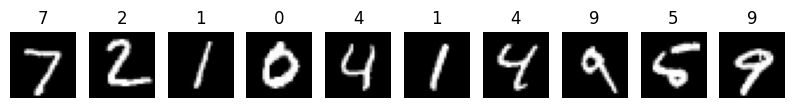

In [5]:
show_images(images, labels, num_images=10 ,bias = 0)

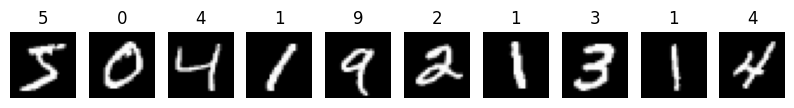

In [6]:
# load train-images.idx3-ubyte
images_train = load_mnist_images('./data/MNIST/raw/train-images-idx3-ubyte')
images_train = np.frombuffer(images_train, np.uint8, offset=16).reshape(-1, 28*28)

# load train-labels.idx1-ubyte
labels_train = load_mnist_labels('./data/MNIST/raw/train-labels-idx1-ubyte')
# 8字节的文件头 + 60000个标签 = 10008字节
labels_train = np.frombuffer(labels_train, np.uint8, offset=8).reshape(-1, 1)

show_images(images_train, labels_train, num_images=10 ,bias = 0)

In [7]:
print(type(images_train))
print(type(labels_train))
print(images_train.shape)
print(labels_train.shape)

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
(60000, 784)
(60000, 1)


In [8]:
X = images_train
y_onehot = labels_train

m,k = X.shape # m 样本数, k 特征数


In [9]:
def sigmoid(x: np.ndarray) -> np.ndarray:
    x = np.clip(x, -500, 500)
    return 1 / (1 + np.exp(-x))

In [10]:
def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True)) # 指数可以无限小，但不能无限大，-maxsoft是为了防止溢出 
    return exp_x / (np.sum(exp_x, axis=1, keepdims=True) + 1e-12)


def cross_entropy_loss(a3, y):
    m = y.shape[0]
    # 确保数值稳定性
    # a3 = np.clip(a3, 1e-12, 1.0 - 1e-12)
    return -np.sum(y * np.log(a3)) / m

使用 `(x - max(x))` 确实改变了前向传播的输入，这会影响反向传播。让我详细推导正确的梯度公式：

---

## 1. 前向传播的修正

设我们实际的 softmax 输入是：
$$
\tilde{z} = z - \max(z)
$$
其中 $$ z $$ 是原始的线性输出。

然后计算：
$$
a = \text{softmax}(\tilde{z}) = \frac{e^{\tilde{z}}}{\sum e^{\tilde{z}}}
$$

---

## 2. 反向传播推导

我们需要计算：
$$
\frac{\partial L}{\partial z} = \frac{\partial L}{\partial a} \cdot \frac{\partial a}{\partial \tilde{z}} \cdot \frac{\partial \tilde{z}}{\partial z}
$$

### 2.1 已知的梯度

对于交叉熵损失 + softmax：
$$
\frac{\partial L}{\partial a} = -\frac{y}{a}
$$
$$
\frac{\partial a_i}{\partial \tilde{z}_j} = a_i (\delta_{ij} - a_j)
$$

所以：
$$
\frac{\partial L}{\partial \tilde{z}_i} = \sum_j \frac{\partial L}{\partial a_j} \frac{\partial a_j}{\partial \tilde{z}_i} = a_i - y_i
$$

**这就是我们熟悉的简洁形式**：$$\delta = a - y$$

---

### 2.2 关键部分：$$\frac{\partial \tilde{z}}{\partial z}$$

$$
\tilde{z}_i = z_i - \max(z)
$$

这里 $$\max(z)$$ 是**不可导**的！但我们可以分析实际情况：

**情况1**：$$z_i$$ 不是最大值
- $\frac{\partial \tilde{z}_i}{\partial z_i} = 1$
- $\frac{\partial \tilde{z}_i}{\partial z_j} = 0$（对 $j \neq i$）

**情况2**：$$z_i$$ 是最大值（假设唯一最大值）
- $\frac{\partial \tilde{z}_i}{\partial z_i} = 0$（因为 $\frac{\partial \max(z)}{\partial z_i} = 1$）
- $\frac{\partial \tilde{z}_i}{\partial z_j} = 0$（对 $j \neq i$）

---

## 5. 数学证明为什么可以忽略 max(z)

虽然我们在前向传播中使用了 $$z - \max(z)$$，但 softmax 的梯度公式 $$a - y$$ 仍然成立，因为：

对于任意常数 $$C$$：
$$
\text{softmax}(z_i - C) = \frac{e^{z_i - C}}{\sum_j e^{z_j - C}} = \frac{e^{z_i}}{\sum_j e^{z_j}} = \text{softmax}(z_i)
$$

因此：
$$
\frac{\partial L}{\partial z_i} = \frac{\partial L}{\partial \text{softmax}(z_i)} \cdot \frac{\partial \text{softmax}(z_i)}{\partial z_i}
= \frac{\partial L}{\partial \text{softmax}(z_i - C)} \cdot \frac{\partial \text{softmax}(z_i - C)}{\partial z_i}
$$

**平移操作不影响梯度**！
---


In [11]:
def cost_func(X:np.ndarray,
              W1:np.ndarray,gamma1:np.ndarray,beta1:np.ndarray,
              W2:np.ndarray,gamma2:np.ndarray,beta2:np.ndarray,
              W3:np.ndarray,
              y:np.ndarray,lambda_reg:float=0.001,epsilon:float=1e-6
              )->float:
    """
    X:(m,k), m is num of samples, k is features
    W1:(k,n1), n1 is num of neurons of layer1
    b1:(1,n1), 
    z1,z1_hat:(m,n1)
    gamma1,beta1:(1,n1)
    z1_tilde:(m,n1), elements_wise multiply
    a1:(m,n1)

    W2:(n1,n2), n2 is num of neurons of layer2
    b2:(1,n2), 
    z2,z2_hat:(m,n2)
    gamma2,beta2:(1,n2)
    z2_tilde:(m,n2), elements_wise multiply
    a2:(m,n2)

    W3:(n2,10)
    b3:(1,10)
    z3:(m,10)
    a3:(m,10)

    y:(m,10):one-hot coding
    ...
    """
    m=y_onehot.shape[0]
    # 可能调整矩阵形状

    z1 = X @ W1# (m,n1)
    # sigma1 = np.sum(np.power((z1-z1.mean(axis=0,keepdims=True)),2),axis=0,keepdims=True) / m # sigma^2
    sigma1 = np.var(z1, axis=0, keepdims=True)  # 推荐这个！
    z1_hat = (z1 - z1.mean(axis=0,keepdims=True))/np.sqrt(sigma1+epsilon)
    z1_tilde = gamma1 * z1_hat + beta1 # 逐元素乘
    a1 = sigmoid(z1_tilde)
    z2 = a1 @ W2
    # sigma2 = np.sum(np.power((z2-z2.mean(axis=0,keepdims=True)),2),axis=0,keepdims=True) / m
    sigma2 = np.var(z2, axis=0, keepdims=True)  # 推荐这个！
    z2_hat = (z2 - z2.mean(axis=0,keepdims=True))/np.sqrt(sigma2+epsilon)
    z2_tilde = gamma2 * z2_hat + beta2 # 逐元素乘
    a2 = sigmoid(z2_tilde)
    z3 = a2 @ W3
    a3 = softmax(z3)

    #  # 数值稳定性处理
    a3 = np.clip(a3, 1e-12, 1.0 - 1e-12)

    # Muti_class classicatioin Entropy
    loss = -np.sum(y * np.log(a3))/m

    reg = (np.sum(W1**2) + np.sum(W2**2) + np.sum(W3**2)) * (lambda_reg / 2)
    return loss + reg

In [12]:
def forward_prop(X:np.ndarray,
              W1:np.ndarray,gamma1:np.ndarray,beta1:np.ndarray,
              W2:np.ndarray,gamma2:np.ndarray,beta2:np.ndarray,
              W3:np.ndarray,
              y_onehot:np.ndarray,
              _predict:bool=False,mu1:float=0,sigma1:float=1,mu2:float=0,sigma2:float=1,
              epsilon:float=1e-6
            ):
    m = y_onehot.shape[0]
    z1 = X @ W1 # (m,n1)
    # sigma1 = np.sum(np.power((z1-z1.mean(axis=0,keepdims=True)),2),axis=0,keepdims=True) / m # sigma^2
    if (_predict==False):
      mu1 = z1.mean(axis=0,keepdims=True)
      sigma1 = np.var(z1, axis=0, keepdims=True)  # 推荐这个！
    z1_hat = (z1 - mu1)/np.sqrt(sigma1+epsilon)
    z1_tilde = gamma1 * z1_hat + beta1 # 逐元素乘
    a1 = sigmoid(z1_tilde)
    z2 = a1 @ W2
    # sigma2 = np.sum(np.power((z2-z2.mean(axis=0,keepdims=True)),2),axis=0,keepdims=True) / m
    if (_predict==False):
      mu2 = z2.mean(axis=0,keepdims=True)
      sigma2 = np.var(z2, axis=0, keepdims=True)  # 推荐这个！
    z2_hat = (z2 - mu2)/np.sqrt(sigma2+epsilon)
    z2_tilde = gamma2 * z2_hat + beta2 # 逐元素乘
    a2 = sigmoid(z2_tilde)
    z3 = a2 @ W3
    a3 = softmax(z3)

    return a3,a2,z2_hat,mu2,sigma2,a1,z1_hat,mu1,sigma1


### 实际实现过程中，我们可以忽略b参数
因为bn在隐藏层对输入分布mean和varience进行重塑，b参数起到偏移分布作用,功能重复，可以抛弃

In [13]:
def BN_backward(delta_hat:np.ndarray,z_hat:np.ndarray,sigma:np.ndarray,gamma:np.ndarray,epsilon:float=1e-6)->np.ndarray:
    m = delta_hat.shape[0]
    B = delta_hat.sum(axis=0,keepdims=True) / m
    C = (delta_hat * z_hat).sum(axis=0,keepdims=True) / m
    D = z_hat * C

    # return delta
    return ( gamma / np.sqrt(sigma + epsilon) ) * (delta_hat - B -D)



In [14]:
# 随机初始化权重为小值， 以便找到权重对输入输出的影响
def randInitializeWeights(L_in: int, L_out: int) -> np.ndarray:
    epsilon_init = np.sqrt(6/(L_in + L_out))
    # 随机初始化权重矩阵W，范围在[-epsilon_init, epsilon_init]
    W = np.random.rand(L_in, L_out) * 2 * epsilon_init - epsilon_init
    return W



In [15]:
def EWA(V,Adam_beta1,d):
    return Adam_beta1 * V + (1-Adam_beta1) * d
    


In [16]:
def RMSprop(S,Adam_beta2,d):
    return Adam_beta2 * S + (1-Adam_beta2) * np.power(d,2)
    


In [17]:
def Adam(V,S,Adam_beta1,Adam_beta2,Para,d,iter,alpha,epsilon=1e-6):
    V_new = EWA(V,Adam_beta1,d)
    S_new = RMSprop(S,Adam_beta2,d)
    V_corrected = V_new / (1-np.power(Adam_beta1,iter + 1)) # iter 从0 开始
    S_corrected = S_new / (1-np.power(Adam_beta2,iter + 1))
    update=Para - alpha * V_corrected / np.sqrt(S_corrected + epsilon)
    return update,V_new,S_new


In [18]:
# 在训练循环中添加梯度检查
def check_gradients(gradients_dict):
    all_zero = True
    for name, grad in gradients_dict.items():
        if np.any(grad != 0):
            all_zero = False
            # print(f"{name} gradient norm: {np.linalg.norm(grad)}")
        else:
            print(f"{name} gradient is ZERO!")
    return all_zero

In [19]:
data = np.load('model_and_cost.npz')
# W1 = data['W1']
# b1 = data['b1']
# # ... 其他参数同理
# cost_history = data['cost_history']

In [20]:
def Batch_Norm_Gradient_Descent(X:np.ndarray,y_onehot:np.ndarray,
                                _load:bool=False,
                                batchsize:int=2048, alpha:float=0.5, lambda_reg:float=0.001, iter:int=500,
                                layer1_size:int = 64,layer2_size:int = 32,
                                tolerance:float=1e-18,
                                alpha_decay_rate:float=0.5,
                                Adam_beta1:float=0.9,Adam_beta2:float=0.99,_Adam:bool=True,
                                epsilon:float=1e-6
                            
                                ):
    m,k=X.shape
    
    W1 = randInitializeWeights(k,layer1_size)
    W2 = randInitializeWeights(layer1_size,layer2_size)
    W3 = randInitializeWeights(layer2_size,10)
    gamma1,beta1= np.ones((1,layer1_size)), np.zeros((1,layer1_size))
    gamma2,beta2 = np.ones((1,layer2_size)), np.zeros((1,layer2_size))

    Vmu2,Vsigma2,Vmu1,Vsigma1 = 0,0,0,0

    cost_history = []
    # Adam parameter
    VdW1, VdW2, VdW3, Vdgamma1, Vdbeta1, Vdgamma2, Vdbeta2 = \
        np.zeros((k,layer1_size)),\
        np.zeros((layer1_size,layer2_size)),\
        np.zeros((layer2_size,10)),\
        np.zeros((1,layer1_size)),np.zeros((1,layer1_size)),\
        np.zeros((1,layer2_size)),np.zeros((1,layer2_size))
    SdW1, SdW2, SdW3, Sdgamma1, Sdbeta1, Sdgamma2, Sdbeta2 = \
        np.zeros((k,layer1_size)),\
        np.zeros((layer1_size,layer2_size)),\
        np.zeros((layer2_size,10)),\
        np.zeros((1,layer1_size)),np.zeros((1,layer1_size)),\
        np.zeros((1,layer2_size)),np.zeros((1,layer2_size))
    
    if _load:
        data = np.load('model_and_cost2.npz')
        W1,gamma1,beta1 = data['W1'],data['gamma1'],data['beta1']
        W2,gamma2,beta2 = data['W2'],data['gamma2'],data['beta2']
        W3 = data['W3']
        Vmu2,Vsigma2,Vmu1,Vsigma1 = data['Vmu2'],data['Vsigma2'],data['Vmu1'],data['Vsigma1']
        VdW1, VdW2, VdW3, Vdgamma1, Vdbeta1, Vdgamma2, Vdbeta2 = \
            data['VdW1'], data['VdW2'], data['VdW3'], data['Vdgamma1'], data['Vdbeta1'], data['Vdgamma2'], data['Vdbeta2']
        SdW1, SdW2, SdW3, Sdgamma1, Sdbeta1, Sdgamma2, Sdbeta2 = \
            data['SdW1'], data['SdW2'], data['SdW3'], data['Sdgamma1'], data['Sdbeta1'], data['Sdgamma2'], data['Sdbeta2']
        alpha=data['alpha']
        cost_history = list(data['cost_history'])
    
        
    
    

    
    for _ in range(iter):
        batch_num = int(m/batchsize) # better makesure batchsize devide m
        for i in range(batch_num):
            
            X_batch = X[i*batchsize:(i+1)*batchsize,:]
            y_batch = y_onehot[i*batchsize:(i+1)*batchsize,:]

            a3,a2,z2_hat,mu2,sigma2,a1,z1_hat,mu1,sigma1 = forward_prop(X_batch,W1,gamma1,beta1,
                                                                W2,gamma2,beta2,
                                                                W3,y_batch)
            
            Vmu2,Vsigma2,Vmu1,Vsigma1 = EWA(Vmu2,Adam_beta1,mu2),EWA(Vsigma2,Adam_beta1,sigma2),EWA(Vmu1,Adam_beta1,mu1),EWA(Vsigma1,Adam_beta1,sigma1)

            delta3 = (a3 - y_batch) # (m,10),!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!教训，写反a3导致一直在高cost收敛
            gradient_W3 = a2.T @ delta3 # (m,n2).T @ (m,10)
            
            # # 
            # gradient_W3 = aggressive_gradient_clipping(gradient_W3, max_norm=1.0)
            # gradient_b3 = aggressive_gradient_clipping(gradient_b3, max_norm=1.0)
            
            delta2_hat = (delta3 @ W3.T) * (a2 * (1-a2)) # (m,n3) (n2,n3).T
            gradient_gamma2 = (delta2_hat * z2_hat).sum(axis=0,keepdims=1) # (m,n2) * (m,n2) Sum^(m) -> (1,n2)
            gradient_beta2 = delta2_hat.sum(axis=0,keepdims=1) # (1,n2)

            delta2 = BN_backward(delta2_hat,z2_hat,sigma2,gamma2,epsilon)
            gradient_W2 = a1.T @ delta2 # (m,n1).T @ (m,n2)

            delta1_hat = (delta2 @ W2.T) * (a1 * (1-a1))
            gradient_gamma1 = (delta1_hat * z1_hat).sum(axis=0,keepdims=1)
            gradient_beta1 = delta1_hat.sum(axis=0,keepdims=1)

            delta1 = BN_backward(delta1_hat,z1_hat,sigma1,gamma1,epsilon)
            gradient_W1 = X_batch.T @ delta1 # (m,k).T @ (k,n1)

            # 正则化
            gradient_W1 += lambda_reg * W1
            gradient_W2 += lambda_reg * W2
            gradient_W3 += lambda_reg * W3

            # Adam
            if _Adam:
                W1,VdW1,SdW1 = Adam(VdW1,SdW1,Adam_beta1,Adam_beta2,W1,gradient_W1,_,alpha,epsilon)
                W2,VdW2,SdW2 = Adam(VdW2,SdW2,Adam_beta1,Adam_beta2,W2,gradient_W2,_,alpha,epsilon)
                W3,VdW3,SdW3 = Adam(VdW3,SdW3,Adam_beta1,Adam_beta2,W3,gradient_W3,_,alpha,epsilon)   
                gamma1,Vdgamma1,Sdgamma1 = Adam(Vdgamma1,Sdgamma1,Adam_beta1,Adam_beta2,gamma1,gradient_gamma1,_,alpha,epsilon)
                beta1,Vdbeta1,Sdbeta1 = Adam(Vdbeta1,Sdbeta1,Adam_beta1,Adam_beta2,beta1,gradient_beta1,_,alpha,epsilon)
                gamma2,Vdgamma2,Sdgamma2 = Adam(Vdgamma2,Sdgamma2,Adam_beta1,Adam_beta2,gamma2,gradient_gamma2,_,alpha,epsilon)
                beta2,Vdbeta2,Sdbeta2 = Adam(Vdbeta2,Sdbeta2,Adam_beta1,Adam_beta2,beta2,gradient_beta2,_,alpha,epsilon)
            else:
                W1 = W1 - alpha * gradient_W1
                W2 = W2 - alpha * gradient_W2
                W3 = W3 - alpha * gradient_W3
                gamma1 = gamma1 - alpha * gradient_gamma1
                beta1 = beta1 - alpha * gradient_beta1
                gamma2 = gamma2 - alpha * gradient_gamma2
                beta2 = beta2 - alpha * gradient_beta2
                
        cost = cost_func(X,W1,gamma1,beta1,W2,gamma2,beta2,W3,y_onehot)

        if ( _ > 0 and cost_history[-1] > cost):
            alpha *= 1.05
        else:
            alpha *=0.75
        if ( _ > 0 and np.abs(cost_history[-1] - cost) < tolerance ):
            cost_history.append(cost)
            break
        cost_history.append(cost)
        # alpha = 1 / (1 + np.power(alpha_decay_rate,_)) * alpha0
        if (_+1) % 100==0:
            print(f"{_+1} / {iter} iterations")
            print(f"cost:{cost}\n")
            
        # # check gradient
        # gradients = {
        # 'W1': gradient_W1, 'W2': gradient_W2, 'W3': gradient_W3,
        # 'b1': gradient_b1, 'b2': gradient_b2, 'b3': gradient_b3,
        # 'gamma1': gradient_gamma1, 'gamma2': gradient_gamma2,
        # 'beta1': gradient_beta1, 'beta2': gradient_beta2
        # }
        # if _ % 10 == 0:
        #     print(f"Iteration {_}:")
        # check_gradients(gradients)

    # 保存模型参数和cost_history
    np.savez('model_and_cost2.npz',
            W1=W1, gamma1=gamma1, beta1=beta1,
            W2=W2, gamma2=gamma2, beta2=beta2,
            W3=W3,
            Vmu2=Vmu2,Vsigma2=Vsigma2,Vmu1=Vmu1,Vsigma1=Vsigma1,
            VdW1=VdW1, VdW2=VdW2, VdW3=VdW3, Vdgamma1=Vdgamma1, Vdbeta1=Vdbeta1, Vdgamma2=Vdgamma2, Vdbeta2=Vdbeta2,
            SdW1=SdW1, SdW2=SdW2, SdW3=SdW3, Sdgamma1=Sdgamma1, Sdbeta1=Sdbeta1, Sdgamma2=Sdgamma2, Sdbeta2=Sdbeta2,
            alpha=alpha,
            cost_history=np.array(cost_history))

    return W1,gamma1,beta1,W2,gamma2,beta2,W3,Vmu2,Vsigma2,Vmu1,Vsigma1,cost_history
        


In [21]:
# read data
X = images_train
y = labels_train
# print(X)
# print(y)

X = X

# transform onehot
m = y.shape[0]
y_onehot = np.zeros((m, 10))
y_onehot[np.arange(m), y.flatten()] = 1
# train the model

W1,gamma1,beta1,W2,gamma2,beta2,W3,Vmu2,Vsigma2,Vmu1,Vsigma1,cost_history = Batch_Norm_Gradient_Descent(
    X,y_onehot,_load=1,layer1_size=128,layer2_size=64
)


100 / 500 iterations
cost:4.057145379369512

200 / 500 iterations
cost:4.170630488624191

300 / 500 iterations
cost:3.4298667722116485

400 / 500 iterations
cost:2.928122315377714

500 / 500 iterations
cost:3.4370008249570643



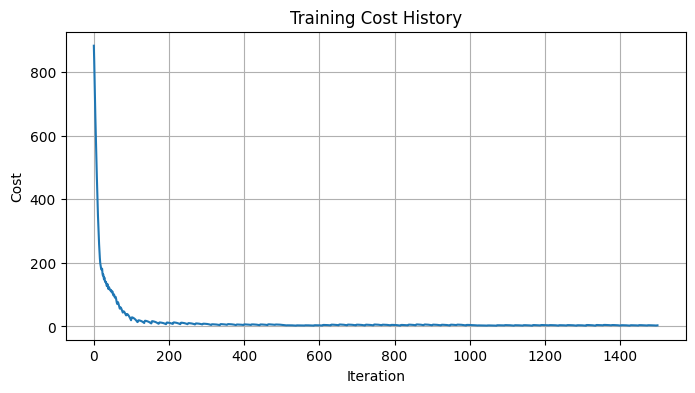

In [22]:
# plot the cost history
# plot the cost history
plt.figure(figsize=(8,4))
plt.plot(cost_history)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Training Cost History')
plt.grid(True)
plt.show()

# cost_history

In [23]:
# check credibility
a3,_,_,_,_,_,_,_,_ = forward_prop(X,W1,gamma1,beta1,W2,gamma2,beta2,W3,y_onehot,1,Vmu1,Vsigma1,Vmu2,Vsigma2) # 改用历史sigma和mu准确率有所下降
predicted = np.argmax(softmax(a3),axis=1,keepdims=1)
print(predicted)
print(y)
idx_correct = predicted==y
print(idx_correct.shape,predicted.shape)

cred = np.sum(idx_correct) / idx_correct.shape[0]
print(cred)


[[5]
 [0]
 [4]
 ...
 [5]
 [6]
 [8]]
[[5]
 [0]
 [4]
 ...
 [5]
 [6]
 [8]]
(60000, 1) (60000, 1)
0.9996666666666667


In [24]:

X_test = images 
y_test = labels 

X_test = X_test

print(images.shape,labels.shape)
# transform onehot
m_test = y_test.shape[0]
y_onehot = np.zeros((m_test, 10))
y_onehot[np.arange(m_test), y_test.flatten()] = 1
# train the model
predicted_test,_,_,_,_,_,_,_,_ = forward_prop(X_test,W1,gamma1,beta1,W2,gamma2,beta2,W3,y_onehot,1,Vmu1,Vsigma1,Vmu2,Vsigma2)
predicted_test = np.argmax(softmax(predicted_test),axis=1,keepdims=1)
print(predicted_test.shape)
print(y_test.shape)
# 改用历史sigma和mu准确率有所下降,但是确保了预测单个样本的功能
idx_correct = predicted_test==y_test
print(idx_correct.shape,predicted_test.shape)

cred = np.sum(idx_correct) / idx_correct.shape[0]
print(cred)

(10000, 784) (10000, 1)


(10000, 1)
(10000, 1)
(10000, 1) (10000, 1)
0.9787


In [25]:
def display_data(X):
    m, n = X.shape # m是样本数，n是特征数
    example_width = int(np.round(np.sqrt(n))) # 假设每个样本是一个正方形
    example_height = n // example_width # 每个样本的高度  //（floor division)是向下取整
    display_rows = int(np.floor(np.sqrt(m))) # 显示的行数, floor是向下取整
    display_cols = int(np.ceil(m / display_rows)) # 显示的列数, ceil是向上取整
    
    pad = 1 # 每个样本之间的间隔, 1个像素, 黑框
    display_array = -np.ones((pad + display_rows * (example_height + pad), 
                              pad + display_cols * (example_width + pad)))
    
    curr_ex = 0
    for j in range(display_rows):
        for i in range(display_cols):
            if curr_ex >= m:
                break
            max_val = np.max(np.abs(X[curr_ex, :]))
            row_start = pad + j * (example_height + pad)
            col_start = pad + i * (example_width + pad)
            display_array[row_start:row_start + example_height, 
                          col_start:col_start + example_width] = \
                X[curr_ex, :].reshape(example_height, example_width).T / max_val
            curr_ex += 1
    
    plt.imshow(display_array, cmap='gray')
    plt.axis('off')
    plt.show()
# display_data(X_sample)  # 显示随机选择的样本

(213, 784)


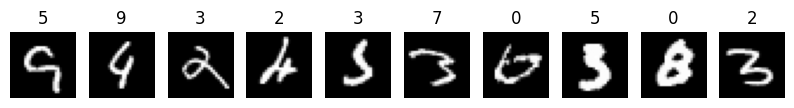

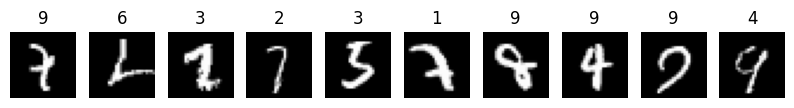

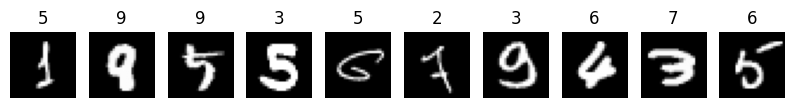

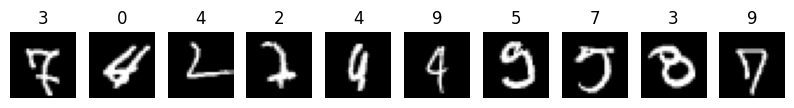

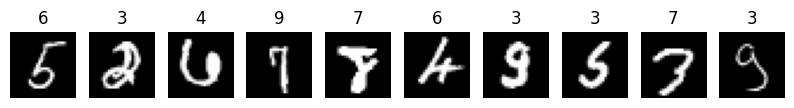

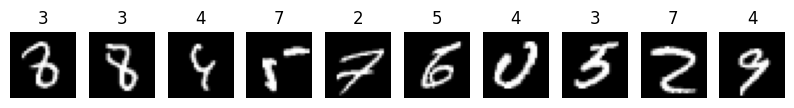

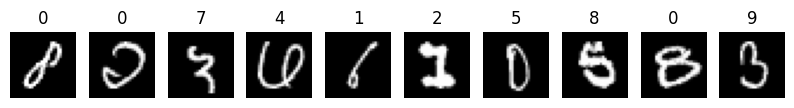

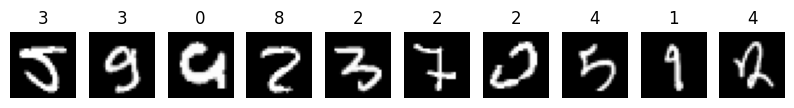

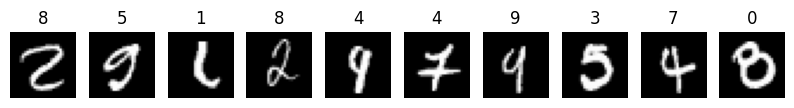

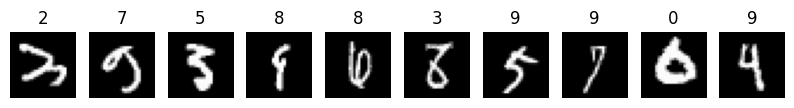

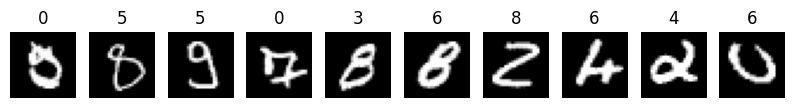

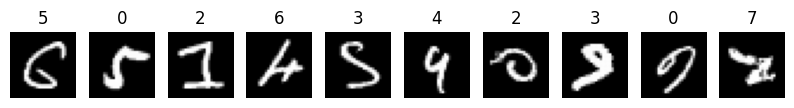

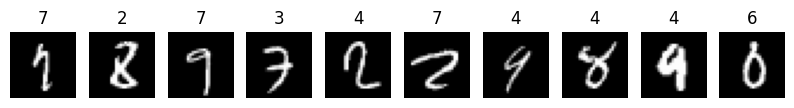

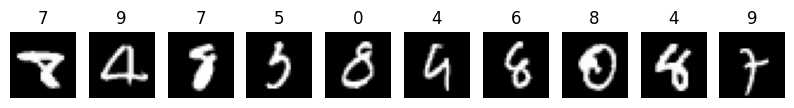

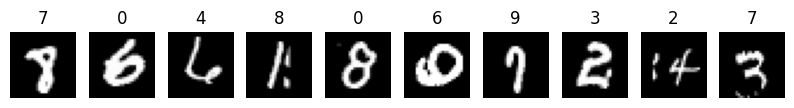

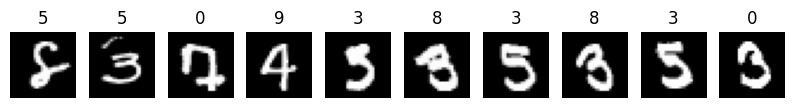

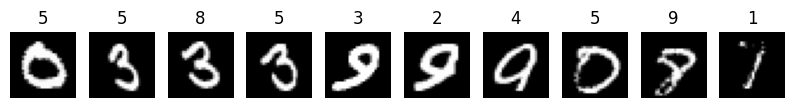

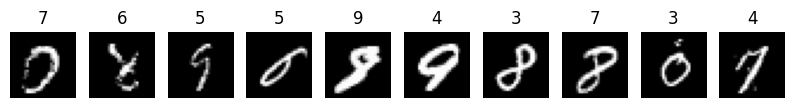

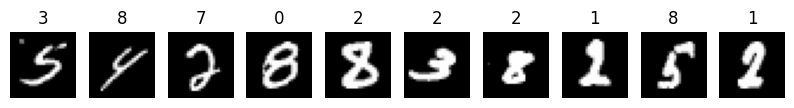

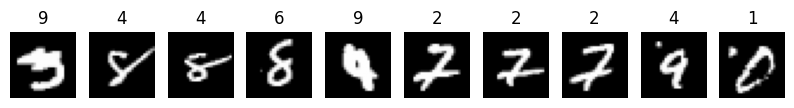

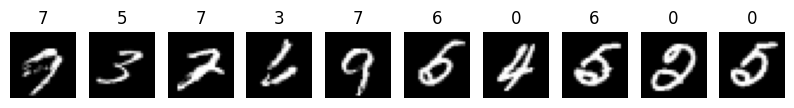

In [26]:
# plot the wrong result
idx_wrong = predicted_test.flatten() != y_test.flatten()
X_wrong = X_test[idx_wrong]
print(X_wrong.shape)

# display_data(X_wrong.T)
# display_data(X_wrong.T)
for _ in range(int(X_wrong.shape[0]/10)):
    show_images(X_wrong,predicted_test[idx_wrong],10,_*10)